In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, ReLU, LayerNormalization, Concatenate, LSTM, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

def create_cnn_branch(input_tensor, stride_val, branch_name):
    x = Conv1D(filters=16, kernel_size=3, strides=stride_val, padding='causal', 
                kernel_regularizer=l2(0.01),
                name=f"{branch_name}_conv1")(input_tensor)
    
    x = ReLU(name=f"{branch_name}_relu1")(x)
    
    x = LayerNormalization(name=f"{branch_name}_norm1")(x)
        
    x = Conv1D(filters=32, kernel_size=3, strides=1, padding='causal', 
                kernel_regularizer=l2(0.01),
                name=f"{branch_name}_conv2")(x)
    
    x = ReLU(name=f"{branch_name}_relu2")(x)
    x = LayerNormalization(name=f"{branch_name}_norm2")(x)
    
    return x

def build_model(num_classes=2):    
    input_hand_gsr = Input(shape=(1860, 1), name="input_hand_GSR")
    branch_hand_gsr = create_cnn_branch(input_hand_gsr, stride_val=2, branch_name="hand_GSR")
    
    input_foot_gsr = Input(shape=(1860, 1), name="input_foot_GSR")
    branch_foot_gsr = create_cnn_branch(input_foot_gsr, stride_val=2, branch_name="foot_GSR")
    
    input_resp = Input(shape=(1860, 1), name="input_RESP")
    branch_resp = create_cnn_branch(input_resp, stride_val=2, branch_name="RESP")
    
    input_hr = Input(shape=(930, 1), name="input_HR")
    branch_hr = create_cnn_branch(input_hr, stride_val=1, branch_name="HR")
    
    input_emg = Input(shape=(930, 1), name="input_EMG")
    branch_emg = create_cnn_branch(input_emg, stride_val=1, branch_name="EMG")

    merged_features = Concatenate(axis=-1, name="fusion_concat")([
        branch_hand_gsr, branch_foot_gsr, branch_resp, branch_hr, branch_emg
    ])

    lstm_out = LSTM(units=64, return_sequences=False, name="lstm_layer")(merged_features)
    
    lstm_out = Dropout(0.5, name="dropout")(lstm_out)
    
    output_layer = Dense(units=num_classes, activation='softmax', name="output_softmax")(lstm_out)

    model = Model(
        inputs=[input_hand_gsr, input_foot_gsr, input_resp, input_hr, input_emg],
        outputs=output_layer,
        name="Multibranch_Model"
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model

In [4]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from sklearn.utils.class_weight import compute_class_weight

def train_model(npz_path, save_model_dir='/content/drive/MyDrive/data/saved_models'):
    print(f"\n{'='*60}")
    print("G. Second layer - High / Medium Stress")
    
    data = np.load(npz_path)
    
    sensor_order = ['hand_GSR', 'foot_GSR', 'RESP', 'HR', 'EMG']
    
    X_all = [data[sensor] for sensor in sensor_order]
    y_all = data['labels']
    groups = data['driver_groups']
    
    unique_groups = np.unique(groups)
    
    logo = LeaveOneGroupOut()
    metrics_list = []
    accumulated_cm = np.zeros((2, 2), dtype=int)
    X_dummy = np.zeros(len(y_all)) 
    
    os.makedirs(save_model_dir, exist_ok=True)
    
    for fold, (train_idx, val_idx) in enumerate(logo.split(X_dummy, y_all, groups)):
        test_driver = groups[val_idx][0]
        
        X_train_list = [branch[train_idx] for branch in X_all]
        X_val_list = [branch[val_idx] for branch in X_all]
        y_train, y_val = y_all[train_idx], y_all[val_idx]
        
        print(f"\n🔄 Fold {fold+1:02d} | Hold-out Driver: {test_driver} | Train: {len(y_train)} | Val: {len(y_val)}")
        
        tf.keras.backend.clear_session()
        model = build_model()
        
        checkpoint_path = f"{save_model_dir}/best_model_{test_driver}.keras"
        callbacks = [
            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0),
            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', save_best_only=True, mode='min', verbose=0)
        ]
        
        class_weights = compute_class_weight(
            class_weight='balanced', 
            classes=np.unique(y_train), 
            y=y_train
        )
        weight_dict = {0: class_weights[0], 1: class_weights[1]}
        
        model.fit(
            x=X_train_list, 
            y=y_train,
            validation_data=(X_val_list, y_val),
            epochs=60,
            batch_size=20,
            class_weight=weight_dict,
            callbacks=callbacks,
            verbose=0
        )
        
        y_pred_prob = model(X_val_list, training=False).numpy()
        y_pred = np.argmax(y_pred_prob, axis=1)
        
        acc = accuracy_score(y_val, y_pred)
        rec = recall_score(y_val, y_pred, zero_division=0)
        prec = precision_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        
        cm = confusion_matrix(y_val, y_pred, labels=[1, 0])
        accumulated_cm += cm
        
        tn, fp = cm[1, 1], cm[1, 0]
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        metrics_list.append({
            'Test_Driver': test_driver, 'Accuracy': acc, 'Sensitivity': rec, 
            'Precision': prec, 'Specificity': spec, 'F1_Score': f1
        })
        
        print(f"Acc: {acc*100:.2f}% | F1_Score: {f1*100:.2f}%")

    results_df = pd.DataFrame(metrics_list)
    print("\n" + "-"*60)
    print("Average Result")
    print(results_df.mean(numeric_only=True).to_string())
    
    plot_cm(accumulated_cm)
    
    return results_df

def plot_cm(cm):
    plt.figure(figsize=(8, 8))
    labels = ['High Stress (1)', 'Medium Stress (0)']
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    plt.title('Accumulated Temporal Fusion CM (LODO)', fontweight='bold', pad=40)
    plt.xlabel('Predicted Label', fontweight='bold', labelpad=15)
    plt.ylabel('True Label', fontweight='bold')
    plt.tight_layout()
    plt.show()


G. Second layer - High / Medium Stress

🔄 Fold 01 | Hold-out Driver: drive05 | Train: 859 | Val: 102
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 12.
Acc: 55.88% | F1_Score: 67.15%

🔄 Fold 02 | Hold-out Driver: drive06 | Train: 867 | Val: 94
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 17.
Acc: 82.98% | F1_Score: 85.71%

🔄 Fold 03 | Hold-out Driver: drive07 | Train: 854 | Val: 107
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 17.
Acc: 61.68% | F1_Score: 63.72%

🔄 Fold 04 | Hold-out Driver: drive08 | Train: 865 | Val: 96
Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 23.
Acc: 63.54% | F1_Score: 64.65%

🔄 Fold 05 | Hold-out Driver: drive09 | Train: 858 | Val: 103
Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 10.
Acc: 50.49% | F1_Score: 57.85%

🔄 Fold 06 | Hold-out Driver: drive10 | Train: 867 | Val: 94
Epoch 28: e

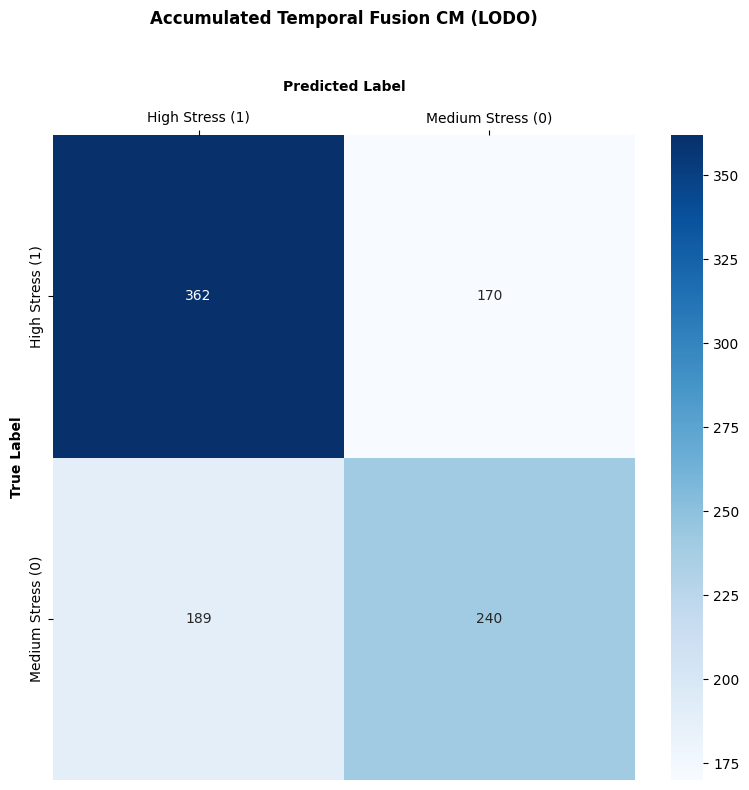

In [ ]:
df_res = train_model('/content/drive/MyDrive/data/dl_data.npz')